In [3]:
%pip install --upgrade numpy pandas datasets

  Using cached datasets-4.8.2-py3-none-any.whl.metadata (19 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 107.4 MB/s  0:00:00
Using cached datasets-4.8.2-py3-none-any.whl (526 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 105.4 MB/s  0:00:00m0:00:01
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 14.0.2
    Uninstalling pyarrow-14.0.2:
      Successfully uninstalled pyarrow-14.0.2
  Attempting uninstall: pandas━━━━━━━━━━━━━━━━━━ 0/3 [pyarrow]
    Found existing installation: pandas 1.5.3 0/3 [pyarrow]
    Uninstalling pandas-1.5.3:╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [pandas]
      Successfully uninstalled pandas-1.5.3━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [pandas]
  Attempting uninstall: datasets━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [pandas]
    Found existing installation: datasets 2.16.1━━━━━━━━━━━━━━ 1/3 [pandas]
    Uninstalling datasets-2.16.1:━╸━━━━━━━━━━━━━ 2/3 [datasets]
      Successfully uninstalled datasets-2.16.190m━━━━━━━━━━━━━ 2/3 [dataset

In [7]:
from transformers import AutoProcessor, AutoModelForCausalLM

model_id = "microsoft/Florence-2-base"
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_id, trust_remote_code=True)

# Florence-2 utilise des "prompts" textuels
# Pour l'Object Detection (OD), le format cible est :
# <OD>{box_2d_1}{label_1}{box_2d_2}{label_2}...

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [8]:
from datasets import Dataset, Features, Image, Sequence, Value, load_dataset
import json

def load_custom_dataset(json_path, img_dir):
    with open(json_path, 'r') as f:
        coco_data = json.load(f)
    
    # On prépare les listes pour le dataset
    images = []
    annotations = []
    
    # On crée un dictionnaire pour regrouper les annotations par image
    img_to_anns = {img['id']: [] for img in coco_data['images']}
    for ann in coco_data['annotations']:
        img_to_anns[ann['image_id']].append(ann)
        
    dataset_dict = {
        "image": [],
        "objects": []
    }

    for img_info in coco_data['images']:
        path = os.path.join(img_dir, img_info['file_name'])
        if os.path.exists(path):
            dataset_dict["image"].append(path)
            
            anns = img_to_anns[img_info['id']]
            dataset_dict["objects"].append({
                "bbox": [a['bbox'] for a in anns],
                "category": [a['category_id'] for a in anns],
                "area": [a['area'] for a in anns],
                "id": [a['id'] for a in anns]
            })
            
    return Dataset.from_dict(dataset_dict).cast_column("image", Image())

# Chargement final
train_ds = load_custom_dataset('dataset/annotations_train.json', 'dataset/train-copy')
test_ds = load_custom_dataset('dataset/annotations_test.json', 'dataset/test-copy')

from datasets import DatasetDict
dataset = DatasetDict({"train": train_ds, "test": test_ds})

In [9]:
import torch

def preprocess_florence(examples):
    images = [img.convert("RGB") for img in examples["image"]]
    
    # Florence-2 utilise un système de coordonnées de 0 à 1000
    # On prépare le texte cible pour l'entraînement
    task_prompt = "<OD>" 
    targets = []
    
    for i in range(len(images)):
        w_img, h_img = images[i].size
        anns = examples["objects"][i]
        
        florence_str = task_prompt
        for bbox in anns["bbox"]:
            x, y, w, h = bbox
            # Normalisation 0-1000
            xmin = int(x * 1000 / w_img)
            ymin = int(y * 1000 / h_img)
            xmax = int((x + w) * 1000 / w_img)
            ymax = int((y + h) * 1000 / h_img)
            
            # Format Florence: <loc_y1><loc_x1><loc_y2><loc_x2>label
            florence_str += f"<loc_{ymin}><loc_{xmin}><loc_{ymax}><loc_{xmax}>field"
        
        targets.append(florence_str)

    # On passe tout au processeur
    inputs = processor(text=[task_prompt] * len(images), images=images, return_tensors="pt", padding=True)
    
    # On ajoute les labels (le texte que le modèle doit apprendre à générer)
    labels = processor.tokenizer(text=targets, return_tensors="pt", padding=True, return_token_type_ids=False).input_ids
    inputs["labels"] = labels
    
    return inputs

# Appliquer la transformation
dataset["train"] = dataset["train"].with_transform(preprocess_florence)
dataset["test"] = dataset["test"].with_transform(preprocess_florence)

In [10]:
def collate_fn(batch):
    return {
        "input_ids": torch.stack([item["input_ids"] for item in batch]),
        "pixel_values": torch.stack([item["pixel_values"] for item in batch]),
        "labels": torch.stack([item["labels"] for item in batch]),
        "attention_mask": torch.stack([item["attention_mask"] for item in batch])
    }

In [6]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./florence2_sap_finetuned",
    per_device_train_batch_size=1,
    num_train_epochs=15,
    learning_rate=2e-5,
    save_total_limit=1,
    logging_steps=5,
    eval_strategy="no",
    use_cpu=True,
    remove_unused_columns=False,
    push_to_hub=False,
    # --- SOLUTION ICI ---
    report_to="none"  # Empêche l'envoi des logs trop longs à Azure MLflow
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    data_collator=collate_fn
)

print("🚀 Relance du Fine-tuning sans logs MLflow...")
trainer.train()

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Step,Training Loss
5,6.475800
10,3.119800
15,4.102900
20,3.552500
25,2.363400
30,2.636300
35,2.448700
40,1.873700
45,2.180400
50,1.979000


TrainOutput(global_step=270, training_loss=1.0727592885494233, metrics={'train_runtime': 5174.3746, 'train_samples_per_second': 0.052, 'train_steps_per_second': 0.052, 'total_flos': 4009759303680.0, 'train_loss': 1.0727592885494233, 'epoch': 15.0})

In [5]:
import os

# Créer le dossier s'il n'existe pas
output_dir = "./florence2_sap_finetuned"
os.makedirs(output_dir, exist_ok=True)

# Sauvegarde du modèle et du processeur depuis la RAM
print("💾 Sauvegarde en cours...")
model.save_pretrained(output_dir)
processor.save_pretrained(output_dir)

print(f"✅ Sauvegarde réussie dans {output_dir} !")

💾 Sauvegarde en cours...


NameError: name 'model' is not defined

In [10]:
%pip install "numpy<2" --force-reinstall

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-ml 0.6.1 requires enum34, which is not installed.
azureml-automl-dnn-nlp 1.61.0 requires accelerate<1.0.0, but you have accelerate 1.13.0 which is incompatible.
azureml-automl-dnn-nlp 1.61.0 requires datasets<=2.16.1,>=1.7.0, but you have datasets 4.8.2 which is incompatible.
azureml-automl-dnn-nlp 1.61.0 requires torch==2.2.2, but you have torch 2.10.0 which is incompatible.
azureml-automl-runtime 1.61.0 requires numpy<=1.23.5,>=1.16.0; python_version >= "3.8", but 

In [11]:
# FORCE LE CHARGEMENT DE TON TRAVAIL
model_path = "./florence2_sap_finetuned" 

processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_path, trust_remote_code=True)
model.to("cpu")
model.eval()
print("✅ Modèle entraîné chargé avec succès !")

✅ Modèle entraîné chargé avec succès !


📊 PERFORMANCES RÉELLES :
   - Poids : 3536.73 MB
   - Vitesse Inférence : 3459.81 ms
🔍 RÉPONSE DU MODÈLE : </s><s>field<loc_0><loc_0><loc_998><loc_998></s>


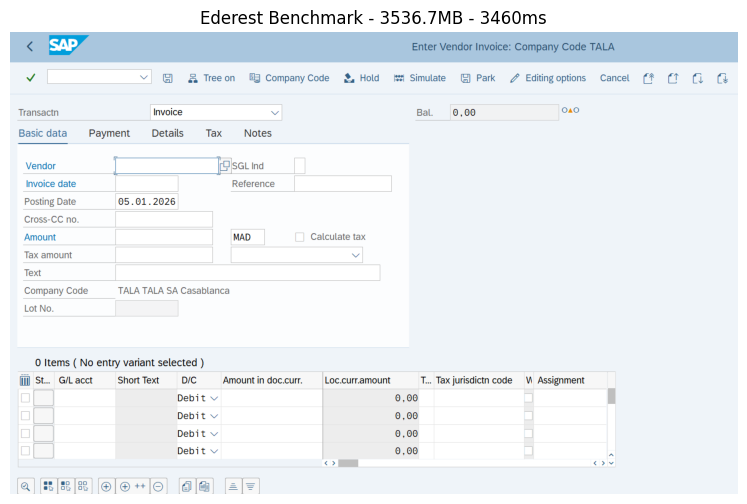

In [15]:
import os
import time
import torch
from PIL import Image as PILImage
import matplotlib.pyplot as plt

# 1. Fonction de mesure de performance
def get_model_metrics(model_dir, model, inputs):
    # --- MESURE DU POIDS ---
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(model_dir):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            total_size += os.path.getsize(fp)
    size_mb = total_size / (1024 * 1024)
    
    # --- MESURE DE LA VITESSE (Inférence) ---
    # Warm-up (préchauffage)
    with torch.no_grad():
        _ = model.generate(**inputs, max_new_tokens=10)
    
    # Mesure sur 3 essais
    start_time = time.time()
    for _ in range(3):
        with torch.no_grad():
            _ = model.generate(**inputs, max_new_tokens=100)
    end_time = time.time()
    avg_speed_ms = ((end_time - start_time) / 3) * 1000
    
    return size_mb, avg_speed_ms

# 2. Ta fonction d'inférence modifiée
def run_florence_inference(image_path, model_dir):
    image = PILImage.open(image_path).convert("RGB")
    prompt = "<CAPTION_TO_PHRASE_GROUNDING> field"
    
    # --- CRÉATION DES INPUTS (Indispensable avant la mesure) ---
    inputs = processor(text=prompt, images=image, return_tensors="pt")
    
    # --- APPEL DES MÉTRIQUES ---
    poids, vitesse = get_model_metrics(model_dir, model, inputs)
    
    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=inputs["input_ids"],
            pixel_values=inputs["pixel_values"],
            max_new_tokens=1024,
            num_beams=5,
            do_sample=False
        )
    
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    
    print(f"📊 PERFORMANCES RÉELLES :")
    print(f"   - Poids : {poids:.2f} MB")
    print(f"   - Vitesse Inférence : {vitesse:.2f} ms")
    print(f"🔍 RÉPONSE DU MODÈLE : {generated_text}")

    # --- AFFICHAGE ---
    parsed_answer = processor.post_process_generation(
        generated_text, task=prompt, image_size=(image.width, image.height)
    )
    
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    ax = plt.gca()
    detections = parsed_answer.get(prompt, parsed_answer.get("<OD>", {}))
    
    if 'bboxes' in detections:
        for bbox in detections['bboxes']:
            xmin, ymin, xmax, ymax = bbox
            rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, 
                                 fill=True, facecolor='red', alpha=0.3, edgecolor='red')
            ax.add_patch(rect)
    
    plt.axis('off')
    plt.title(f"Ederest Benchmark - {poids:.1f}MB - {vitesse:.0f}ms")
    plt.show()

# 3. Lancement
model_path = "./florence2_sap_finetuned"
test_image = "dataset/train-copy/img_1767525774023.png"

if os.path.exists(test_image):
    run_florence_inference(test_image, model_path)